In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!pip install faiss-cpu sentence-transformers -q
print("done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 63.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is inco

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

import warnings
warnings.filterwarnings("ignore")

In [3]:
print("Loading embedding model...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print("Embedding dimension:", len(embedder.encode(["test"])[0]))

Loading embedding model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


In [4]:
print("Loading LLM ")

model_name = "Qwen/Qwen2.5-7B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("LLM ready on:", next(model.parameters()).device)

Loading LLM (takes a few minutes on first run)...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

LLM ready on: cuda:0


In [5]:
class TokenReuseBuffer:
    def __init__(self, similarity_threshold=0.65):
        self.threshold = similarity_threshold
        self.index = faiss.IndexFlatIP(384)   # MiniLM embedding size

        self.texts = []       # every query we've seen
        self.responses = []   # the answer we generated for it
        self.groups = []      # ground-truth topic label for each query

        print(f"TRB ready | threshold = {similarity_threshold}")

    def _embed(self, text):
        vec = embedder.encode([text])[0]
        vec = vec / np.linalg.norm(vec)     # normalize so inner product = cosine similarity
        return vec.astype(np.float32).reshape(1, -1)

    def _count_tokens(self, text):
        return len(tokenizer.encode(text))

    def _generate(self, prompt):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=150, do_sample=False)
        full_text = tokenizer.decode(out[0], skip_special_tokens=True)
        return full_text[len(prompt):].strip()

    def query(self, text, group_id):
        # Step 1: check if anything similar is already stored
        if self.index.ntotal > 0:
            qvec = self._embed(text)
            score, idx = self.index.search(qvec, 1)
            score, idx = float(score[0][0]), int(idx[0][0])
        else:
            score, idx = 0.0, -1

        true_match_was_available = group_id in self.groups   # did we already store a real duplicate?

        if idx != -1 and score >= self.threshold:
            # ===== CACHE HIT: reuse the stored answer, skip the LLM entirely =====
            t0 = time.time()
            response = self.responses[idx]
            matched_group = self.groups[idx]
            latency = time.time() - t0          # just the lookup time — no generation
            is_correct_hit = (matched_group == group_id)
            tokens_saved = self._count_tokens(response)
            cache_hit = True
        else:
            # ===== CACHE MISS: actually run the LLM =====
            t0 = time.time()
            response = self._generate(text)
            latency = time.time() - t0
            self.index.add(self._embed(text))
            self.texts.append(text)
            self.responses.append(response)
            self.groups.append(group_id)
            is_correct_hit = None
            tokens_saved = 0
            cache_hit = False

        return {
            "query": text,
            "group_id": group_id,
            "cache_hit": cache_hit,
            "similarity_score": round(score, 3),
            "is_correct_hit": is_correct_hit,
            "missed_true_duplicate": true_match_was_available and not cache_hit,
            "tokens_saved": tokens_saved,
            "latency_sec": round(latency, 3),
        }


trb = TokenReuseBuffer(similarity_threshold=0.65)

TRB ready | threshold = 0.65


In [6]:
test_queries = []

# ---- Domain: Neural Networks ----
test_queries += [
    ("Explain what a neural network is", "nn_basic"),
    ("What is a neural network in simple terms", "nn_basic"),
    ("What is backpropagation in neural networks", "nn_backprop"),
    ("Explain how backpropagation works", "nn_backprop"),
    ("What is overfitting in deep learning", "nn_overfit"),
    ("How can you prevent a model from overfitting", "nn_overfit"),
    ("What is a convolutional neural network", "nn_cnn"),   # one-off, in-domain, should MISS
]

# ---- Domain: Transformers ----
test_queries += [
    ("What is the transformer architecture", "tf_arch"),
    ("Explain how a transformer model works", "tf_arch"),
    ("Explain self-attention in transformers", "tf_attention"),
    ("What is the self-attention mechanism", "tf_attention"),
    ("How does positional encoding work in transformers", "tf_posenc"),
    ("Why do transformers need positional encoding", "tf_posenc"),
    ("What is beam search", "tf_beam"),   # one-off, in-domain, should MISS
]

# ---- Domain: Python ----
test_queries += [
    ("What is a list comprehension in Python", "py_listcomp"),
    ("Explain Python list comprehensions", "py_listcomp"),
    ("What is a decorator in Python", "py_decorator"),
    ("Explain how Python decorators work", "py_decorator"),
    ("What is the Global Interpreter Lock in Python", "py_gil"),
    ("Explain the GIL in Python", "py_gil"),
    ("What is a generator in Python", "py_generator"),   # one-off, should MISS
]

# ---- Domain: SQL / Databases ----
test_queries += [
    ("What is a primary key in a database", "sql_pk"),
    ("Explain what a primary key does in SQL", "sql_pk"),
    ("What is a JOIN in SQL", "sql_join"),
    ("Explain how SQL JOINs work", "sql_join"),
    ("What is database normalization", "sql_norm"),
    ("Explain normalization in relational databases", "sql_norm"),
    ("What is an index in SQL", "sql_index"),   # one-off, should MISS
]

# ---- Domain: Web Development ----
test_queries += [
    ("What is a REST API", "web_rest"),
    ("Explain what REST APIs are", "web_rest"),
    ("What is CORS in web development", "web_cors"),
    ("Explain what CORS means", "web_cors"),
    ("What is the difference between GET and POST requests", "web_getpost"),
    ("Explain GET vs POST in HTTP", "web_getpost"),
    ("What is a WebSocket", "web_socket"),   # one-off, should MISS
]

# ---- Unrelated general-knowledge questions — pure negative control ----
# None of these should EVER cache-hit, on anything, at any point
general_knowledge = [
    "What's a good recipe for making pasta",
    "How do plants perform photosynthesis",
    "What causes rain to form in clouds",
    "Who wrote the play Romeo and Juliet",
    "What is the capital city of Japan",
    "How many players are on a soccer team",
    "What is the boiling point of water in Celsius",
    "Why do we have seasons on Earth",
    "What is the largest ocean on Earth",
    "How do you make a good cup of coffee",
    "What is the tallest mountain in the world",
    "How does the human heart pump blood",
    "What year did World War 2 end",
    "What is the currency used in the United Kingdom",
    "How do bees make honey",
    "What is the speed of light",
    "Who painted the Mona Lisa",
    "What is the main ingredient in bread",
    "How many continents are there on Earth",
    "What causes earthquakes",
]
test_queries += [(q, f"gk_{i}") for i, q in enumerate(general_knowledge)]

print(f"Total queries: {len(test_queries)}")

Total queries: 55


In [7]:
results = []
for i, (text, group_id) in enumerate(test_queries):
    result = trb.query(text, group_id)
    results.append(result)
    status = "HIT " if result["cache_hit"] else "MISS"
    print(f"[{i+1:02d}/{len(test_queries)}] {status} | sim={result['similarity_score']:.3f} | {text[:55]}")

df = pd.DataFrame(results)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[01/55] MISS | sim=0.000 | Explain what a neural network is
[02/55] HIT  | sim=0.934 | What is a neural network in simple terms
[03/55] HIT  | sim=0.656 | What is backpropagation in neural networks
[04/55] MISS | sim=0.520 | Explain how backpropagation works
[05/55] MISS | sim=0.388 | What is overfitting in deep learning
[06/55] MISS | sim=0.597 | How can you prevent a model from overfitting
[07/55] MISS | sim=0.603 | What is a convolutional neural network
[08/55] MISS | sim=0.263 | What is the transformer architecture
[09/55] HIT  | sim=0.743 | Explain how a transformer model works
[10/55] MISS | sim=0.389 | Explain self-attention in transformers
[11/55] HIT  | sim=0.692 | What is the self-attention mechanism
[12/55] MISS | sim=0.551 | How does positional encoding work in transformers
[13/55] HIT  | sim=0.927 | Why do transformers need positional encoding
[14/55] MISS | sim=0.202 | What is beam search
[15/55] MISS | sim=0.210 | What is a list comprehension in Python
[16/55] HIT  | sim

In [8]:
total = len(df)
hits = df["cache_hit"].sum()
misses = total - hits

# Precision: of everything we called a "hit", how many were ACTUALLY the same topic?
correct_hits = df["cache_hit"] & (df["is_correct_hit"] == True)
precision = correct_hits.sum() / hits if hits > 0 else 0

# Recall: of every real chance to catch a duplicate, how many did we actually catch?
true_dup_opportunities = df["missed_true_duplicate"].sum() + correct_hits.sum()
recall = correct_hits.sum() / true_dup_opportunities if true_dup_opportunities > 0 else 0

false_positive_hits = (df["cache_hit"] & (df["is_correct_hit"] == False)).sum()

print(f"Total queries          : {total}")
print(f"Cache hits             : {hits}  ({hits/total*100:.1f}%)")
print(f"Cache misses           : {misses}")
print(f"Precision (hits that were actually correct) : {precision*100:.1f}%")
print(f"Recall (true duplicates we successfully caught) : {recall*100:.1f}%")
print(f"False-positive hits (wrongly matched)  : {false_positive_hits}")
print(f"Total tokens saved (from skipped generations) : {df['tokens_saved'].sum()}")
print(f"Avg latency — hits  : {df[df['cache_hit']]['latency_sec'].mean():.4f} sec")
print(f"Avg latency — misses: {df[~df['cache_hit']]['latency_sec'].mean():.2f} sec")

Total queries          : 55
Cache hits             : 13  (23.6%)
Cache misses           : 42
Precision (hits that were actually correct) : 92.3%
Recall (true duplicates we successfully caught) : 85.7%
False-positive hits (wrongly matched)  : 1
Total tokens saved (from skipped generations) : 1950
Avg latency — hits  : 0.0000 sec
Avg latency — misses: 9.67 sec


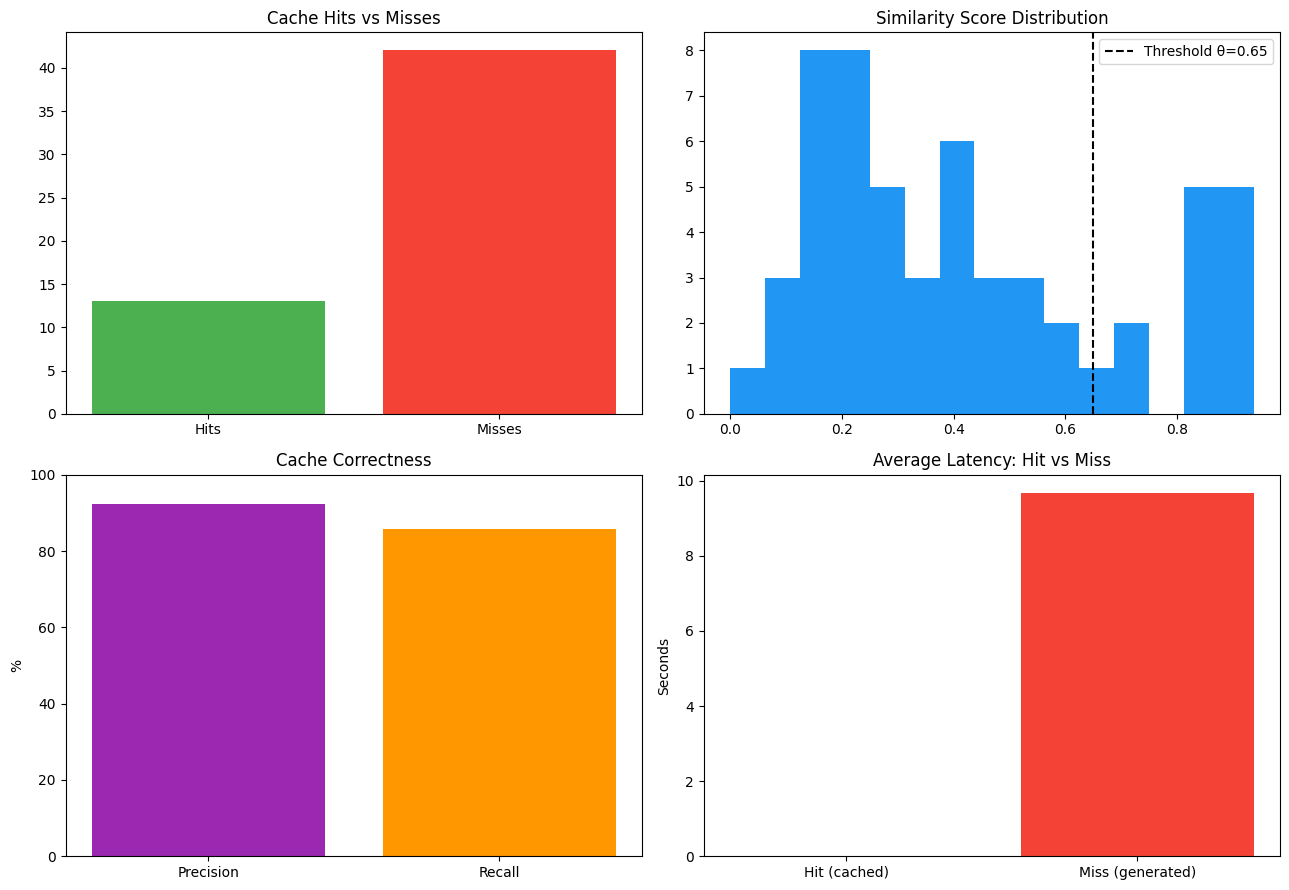

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Hit vs miss counts
axes[0,0].bar(["Hits", "Misses"], [hits, misses], color=["#4CAF50", "#f44336"])
axes[0,0].set_title("Cache Hits vs Misses")

# Similarity score distribution with threshold line
axes[0,1].hist(df["similarity_score"], bins=15, color="#2196F3")
axes[0,1].axvline(0.65, color="black", linestyle="--", label="Threshold θ=0.65")
axes[0,1].set_title("Similarity Score Distribution")
axes[0,1].legend()

# Precision / Recall bar
axes[1,0].bar(["Precision", "Recall"], [precision*100, recall*100], color=["#9C27B0", "#FF9800"])
axes[1,0].set_ylim(0, 100)
axes[1,0].set_title("Cache Correctness")
axes[1,0].set_ylabel("%")

# Latency comparison
axes[1,1].bar(["Hit (cached)", "Miss (generated)"],
              [df[df["cache_hit"]]["latency_sec"].mean(), df[~df["cache_hit"]]["latency_sec"].mean()],
              color=["#4CAF50", "#f44336"])
axes[1,1].set_title("Average Latency: Hit vs Miss")
axes[1,1].set_ylabel("Seconds")

plt.tight_layout()
plt.savefig("trb_results.png", dpi=150)
plt.show()

   threshold  hits  precision
0       0.50    13   0.923077
1       0.55    13   0.923077
2       0.60    13   0.923077
3       0.65    13   0.923077
4       0.70    11   1.000000
5       0.75    10   1.000000
6       0.80    10   1.000000


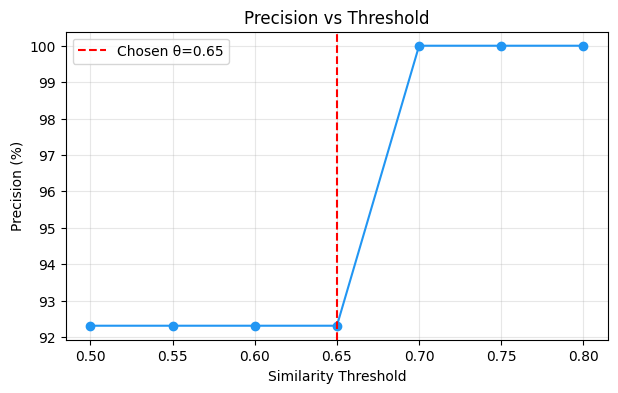

In [10]:
thresholds_to_test = [0.5, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
sensitivity = []

for t in thresholds_to_test:
    hit_mask = df["similarity_score"] >= t
    correct = (hit_mask & (df["is_correct_hit"] == True)).sum()
    total_hits_at_t = (hit_mask & (df["cache_hit"])).sum()  # only counts real search hits, not re-simulated ones
    precision_t = correct / total_hits_at_t if total_hits_at_t > 0 else 0
    sensitivity.append({"threshold": t, "hits": total_hits_at_t, "precision": precision_t})

sens_df = pd.DataFrame(sensitivity)
print(sens_df)

plt.figure(figsize=(7,4))
plt.plot(sens_df["threshold"], sens_df["precision"]*100, marker="o", color="#2196F3")
plt.axvline(0.65, color="red", linestyle="--", label="Chosen θ=0.65")
plt.xlabel("Similarity Threshold")
plt.ylabel("Precision (%)")
plt.title("Precision vs Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("trb_threshold_sensitivity.png", dpi=150)
plt.show()